# Calibration Analysis

- [Parameters](#Parameters)
- [Data Loading](#Data-Loading)
- [Summary Statistics](#Summary-Statistics)
- [Visualizations](#Visualizations)
- [Best/Worst Cases](#Best-Worst-Cases)
- [Environment Info](#Environment-Info)

In [3]:
import os
import pandas as pd

# Parameters
date = '2000-01-01'
detector = 'w2e_out'
number = 0
project_root = os.environ["HORNSGATAN_HOME"]

if number > 0:
    postfix = f"{detector}_{date}_{number}"
else:
    postfix = f"{detector}_{date}"

data_path = os.path.join(project_root, "data/calibration_data", f"calibrated_data_{postfix}.csv")
print("Data path:", data_path)

Data path: /home/kaveh/projects/Hornsgatan/data/calibration_data/calibrated_data_w2e_out_2000-01-01.csv


In [4]:
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Loaded data:", df.shape)
else:
    raise FileNotFoundError(f"File not found: {data_path}")
df.head()

Loaded data: (16, 10)


,veh_id,time_detector_sim,speed_detector_sim,speed_factor,time_detector_real,depart,departSpeed,speed_detector_real,delta_time,delta_speed
0,0_w2e_out,1.708317e+09,4.169277,0.60,1708316618,1708316526,8.3340,3.888889,0.28,0.280388
1,1_w2e_out,1.708319e+09,8.620086,1.05,1708318812,1708318758,14.5845,10.833333,-3.22,-2.213247
2,2_w2e_out,1.708319e+09,4.996696,0.60,1708318980,1708318888,8.3340,6.111111,-0.62,-1.114415
3,3_w2e_out,1.708320e+09,11.294119,1.45,1708319782,1708319743,20.1405,10.833333,-2.28,0.460786
4,4_w2e_out,1.708320e+09,10.333700,1.25,1708320245,1708320202,17.3625,8.888889,-0.62,1.444811


In [5]:
# Show summary stats for error columns
error_cols = ["delta_time", "delta_speed"]
df[error_cols].describe()

,delta_time,delta_speed
count,16.000000,16.000000
mean,-0.162500,-0.162050
std,1.206043,1.373186
min,-3.220000,-3.827515
25%,-0.582500,-0.960708
50%,0.135000,0.336843
75%,0.552500,0.605465
max,1.660000,1.444811


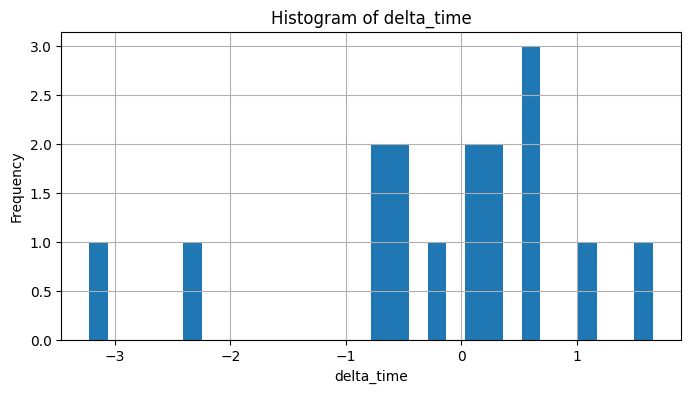

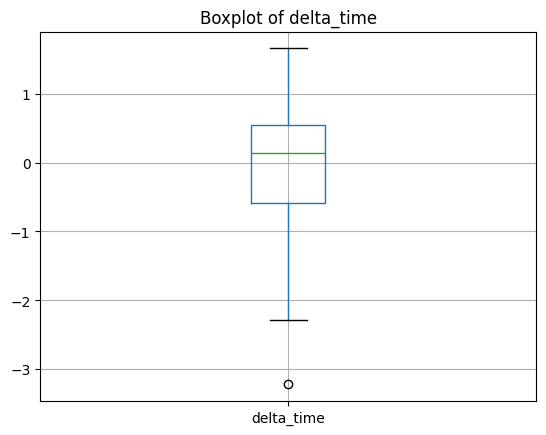

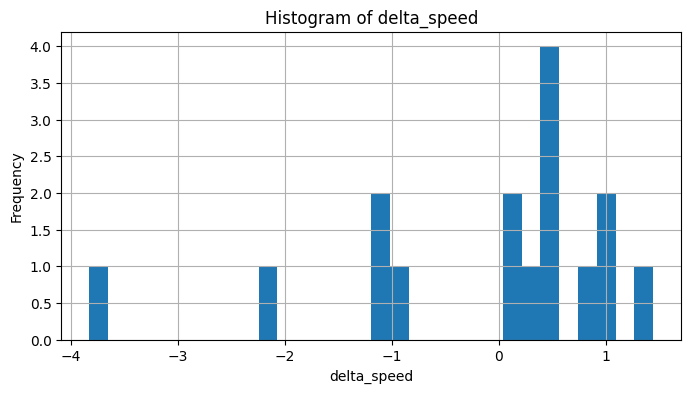

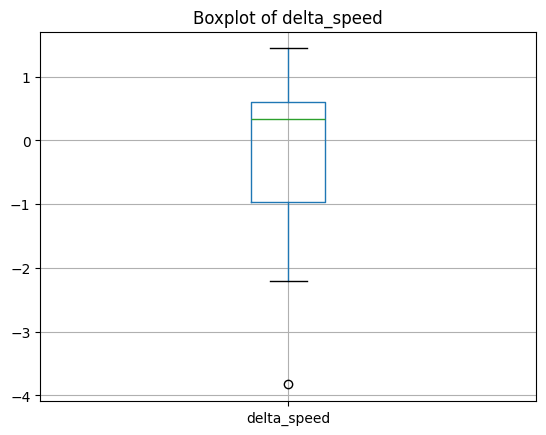

In [6]:
import matplotlib.pyplot as plt

for col in error_cols:
    plt.figure(figsize=(8,4))
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [7]:
# Show rows with smallest/largest delta_time
print("Smallest delta_time:")
display(df.nsmallest(5, "delta_time"))
print("Largest delta_time:")
display(df.nlargest(5, "delta_time"))

Smallest delta_time:


,veh_id,time_detector_sim,speed_detector_sim,speed_factor,time_detector_real,depart,departSpeed,speed_detector_real,delta_time,delta_speed
1,1_w2e_out,1.708319e+09,8.620086,1.05,1708318812,1708318758,14.5845,10.833333,-3.22,-2.213247
3,3_w2e_out,1.708320e+09,11.294119,1.45,1708319782,1708319743,20.1405,10.833333,-2.28,0.460786
2,2_w2e_out,1.708319e+09,4.996696,0.60,1708318980,1708318888,8.3340,6.111111,-0.62,-1.114415
4,4_w2e_out,1.708320e+09,10.333700,1.25,1708320245,1708320202,17.3625,8.888889,-0.62,1.444811
12,12_w2e_out,1.708322e+09,3.731508,0.60,1708321731,1708321638,8.3340,2.777778,-0.57,0.953731


Largest delta_time:


,veh_id,time_detector_sim,speed_detector_sim,speed_factor,time_detector_real,depart,departSpeed,speed_detector_real,delta_time,delta_speed
6,6_w2e_out,1.708321e+09,4.783597,0.6,1708320817,1708320727,8.334,8.611111,1.66,-3.827515
15,15_w2e_out,1.708322e+09,3.787598,0.6,1708322391,1708322300,8.334,3.333333,1.14,0.454264
13,13_w2e_out,1.708322e+09,3.953738,0.6,1708321893,1708321801,8.334,3.055556,0.65,0.898182
14,14_w2e_out,1.708322e+09,4.559964,0.6,1708322172,1708322080,8.334,4.166667,0.56,0.393298
7,7_w2e_out,1.708321e+09,3.845920,0.6,1708321146,1708321054,8.334,5.000000,0.55,-1.154080


1. Distribution Plots (Seaborn)

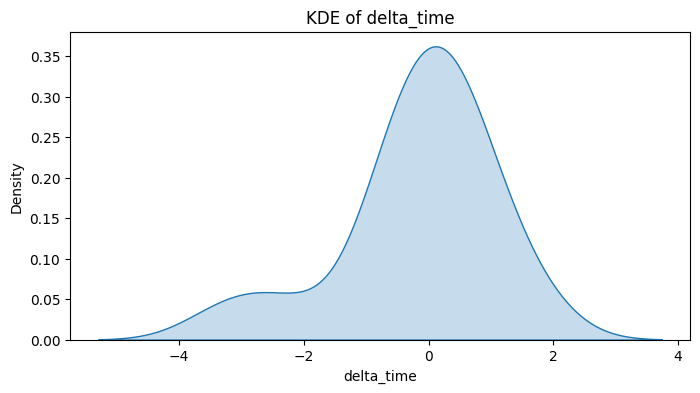

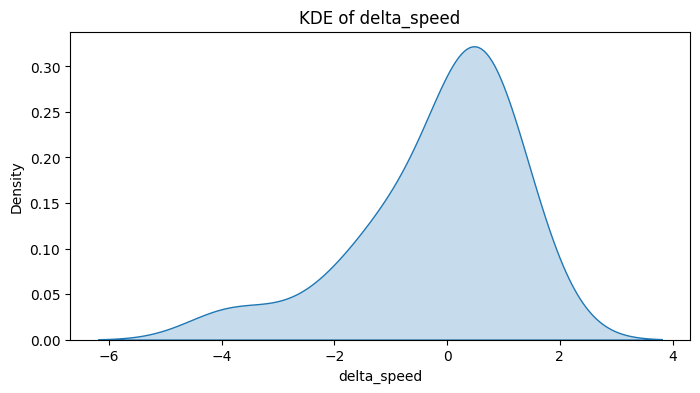

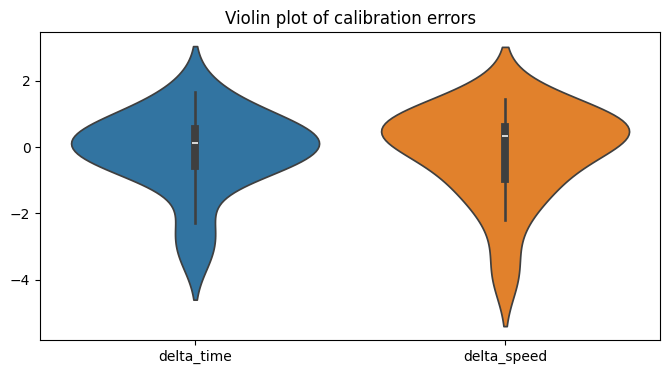

In [8]:
import seaborn as sns

# KDE plot for delta_time and delta_speed
for col in error_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

# Violin plot
plt.figure(figsize=(8,4))
sns.violinplot(data=df[error_cols])
plt.title("Violin plot of calibration errors")
plt.show()

2. Scatter Plot: Simulated vs. Real Values


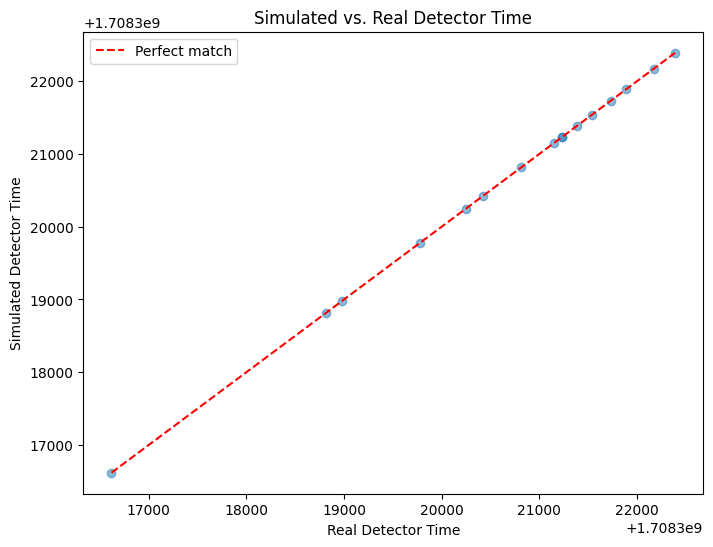

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df['time_detector_real'], df['time_detector_sim'], alpha=0.5)
plt.plot([df['time_detector_real'].min(), df['time_detector_real'].max()],
         [df['time_detector_real'].min(), df['time_detector_real'].max()],
         'r--', label='Perfect match')
plt.xlabel('Real Detector Time')
plt.ylabel('Simulated Detector Time')
plt.title('Simulated vs. Real Detector Time')
plt.legend()
plt.show()

3. Error Over Time


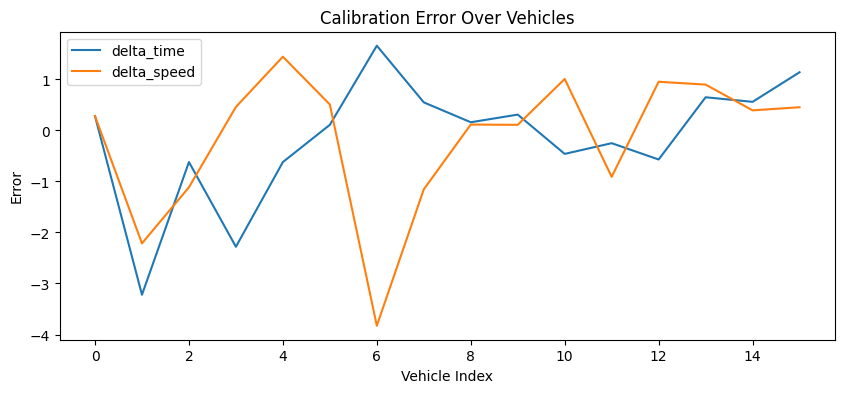

In [10]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

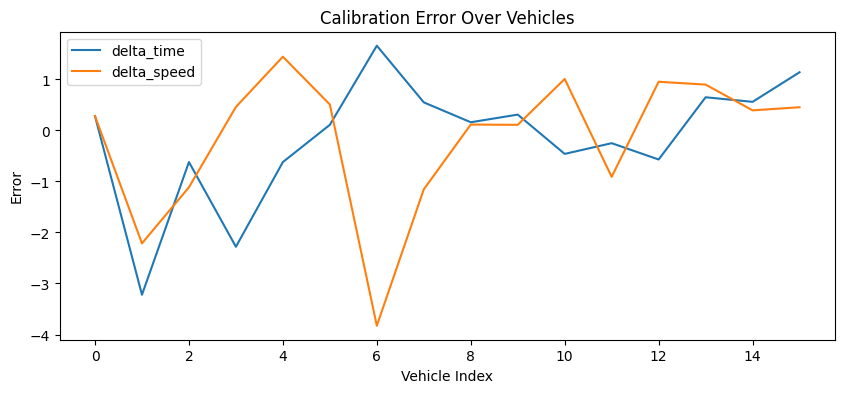

In [11]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

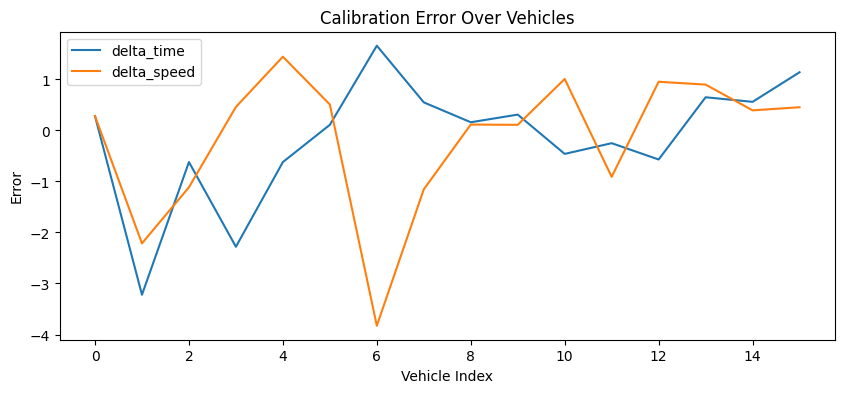

In [12]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

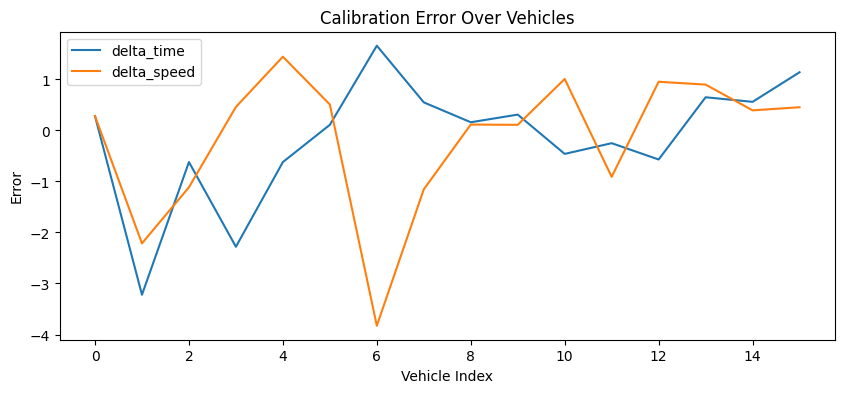

In [13]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

4. Correlation Matrix

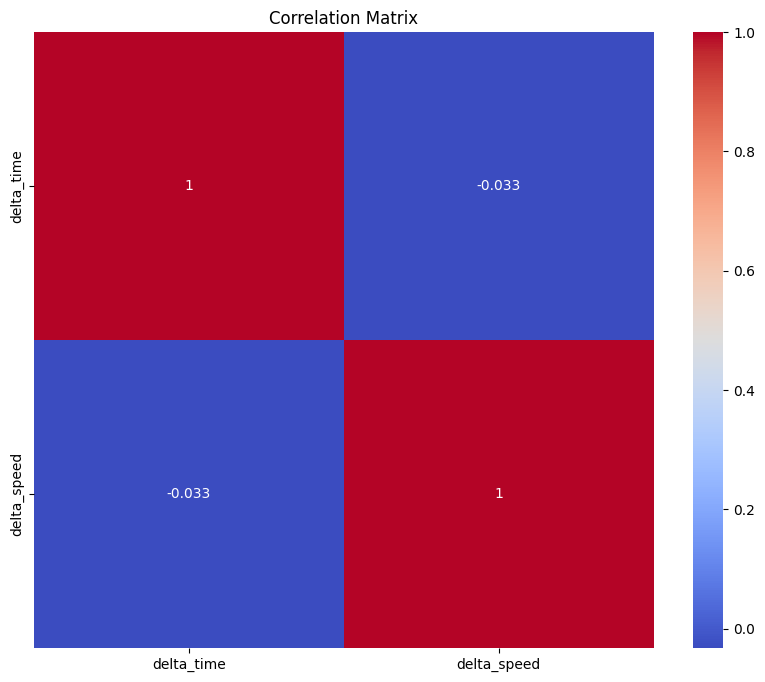

In [14]:
corr = df[["delta_time","delta_speed"]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

5. Outlier Detection


In [15]:
for col in error_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"Number of outliers in {col}: {len(outliers)}")
    display(outliers[[col]].head())

Number of outliers in delta_time: 1


,delta_time
1,-3.22


Number of outliers in delta_speed: 1


,delta_speed
6,-3.827515


6. Error by Speed Factor (if available)


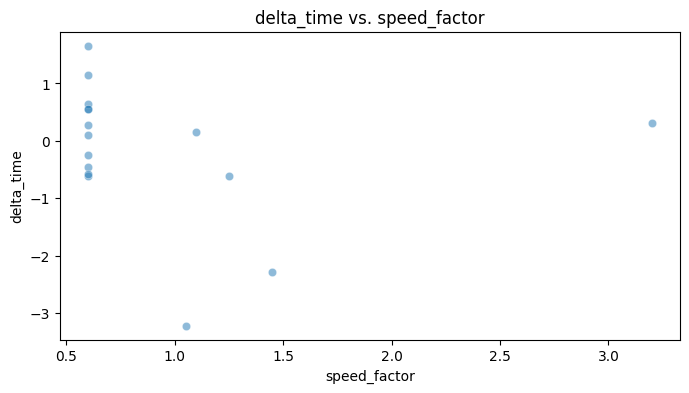

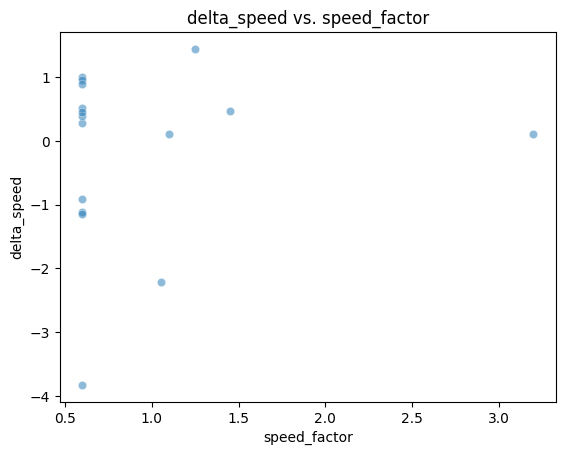

In [16]:
if 'speed_factor' in df.columns:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x='speed_factor', y='delta_time', data=df, alpha=0.5)
    plt.title('delta_time vs. speed_factor')
    plt.show()
    sns.scatterplot(x='speed_factor', y='delta_speed', data=df, alpha=0.5)
    plt.title('delta_speed vs. speed_factor')
    plt.show()

7. Summary Table of Top N Largest Errors

In [17]:
N = 10
df['time_detector_sim'] = df['time_detector_sim'].apply(int)
print("Top N largest delta_time errors:")
display(df.nlargest(N, 'delta_time')[['veh_id', 'delta_speed', 'delta_time', 'time_detector_real', 'time_detector_sim']])
print("Top N largest delta_speed errors:")
display(df.nlargest(N, 'delta_speed')[['veh_id', 'delta_time', 'delta_speed', 'speed_detector_real', 'speed_detector_sim']])

Top N largest delta_time errors:


,veh_id,delta_speed,delta_time,time_detector_real,time_detector_sim
6,6_w2e_out,-3.827515,1.66,1708320817,1708320818
15,15_w2e_out,0.454264,1.14,1708322391,1708322392
13,13_w2e_out,0.898182,0.65,1708321893,1708321893
14,14_w2e_out,0.393298,0.56,1708322172,1708322172
7,7_w2e_out,-1.154080,0.55,1708321146,1708321146
9,9_w2e_out,0.109750,0.31,1708321230,1708321230
0,0_w2e_out,0.280388,0.28,1708316618,1708316618
8,8_w2e_out,0.114600,0.16,1708321228,1708321228
5,5_w2e_out,0.507892,0.11,1708320422,1708320422
11,11_w2e_out,-0.909472,-0.25,1708321543,1708321542


Top N largest delta_speed errors:


,veh_id,delta_time,delta_speed,speed_detector_real,speed_detector_sim
4,4_w2e_out,-0.62,1.444811,8.888889,10.333700
10,10_w2e_out,-0.46,1.008229,3.333333,4.341562
12,12_w2e_out,-0.57,0.953731,2.777778,3.731508
13,13_w2e_out,0.65,0.898182,3.055556,3.953738
5,5_w2e_out,0.11,0.507892,3.888889,4.396781
3,3_w2e_out,-2.28,0.460786,10.833333,11.294119
15,15_w2e_out,1.14,0.454264,3.333333,3.787598
14,14_w2e_out,0.56,0.393298,4.166667,4.559964
0,0_w2e_out,0.28,0.280388,3.888889,4.169277
8,8_w2e_out,0.16,0.114600,8.888889,9.003489


8. Save Plots to Disk


In [18]:
plt.figure(figsize=(8,4))
df['delta_time'].hist(bins=30)
plt.title('Histogram of delta_time')
plt.xlabel('delta_time')
plt.ylabel('Frequency')
plt.savefig('delta_time_histogram.png')
plt.close()